In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
pd.set_option("display.max_columns", None)

In [47]:
sns.set_style("whitegrid")

In [48]:
df = pd.read_csv("data/german_credit_data.csv")

In [49]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [50]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [51]:
df.shape

(1000, 11)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [53]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
df["Job"].unique()

array([2, 1, 3, 0])

In [55]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [56]:
df.duplicated().sum().item()

0

In [57]:
df = df.dropna().reset_index(drop=True)

In [58]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [59]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [60]:
df.drop(columns = 'Unnamed: 0', inplace = True)
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


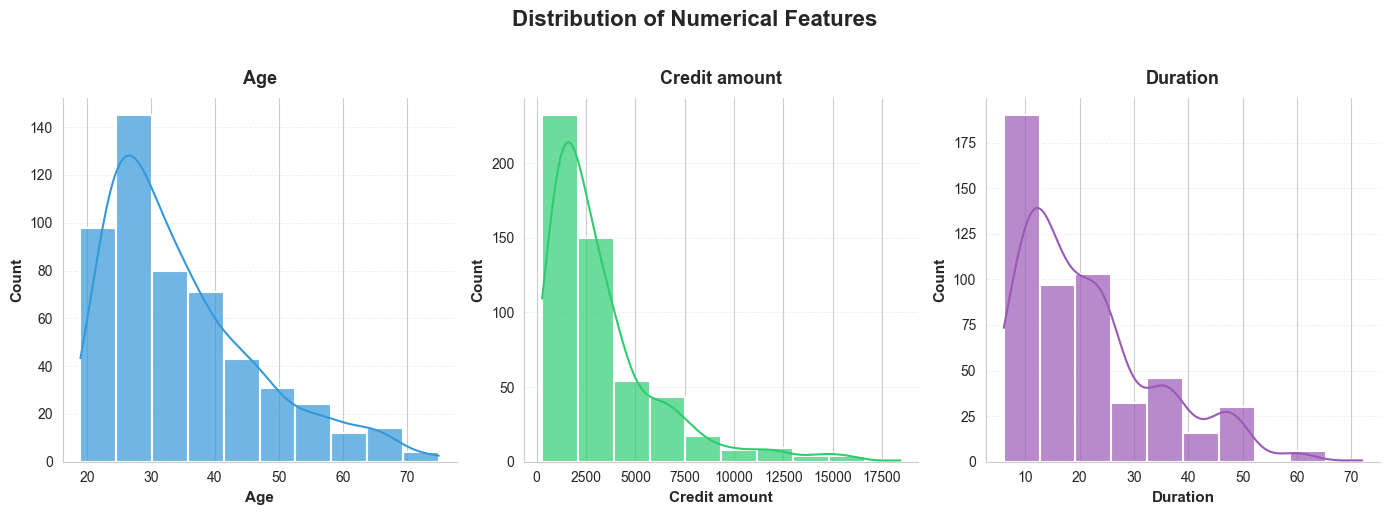

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('white')

colors = ['#3498db', '#2ecc71', '#9b59b6']
columns = ["Age", "Credit amount", "Duration"]

axes_flat = axes.flatten()

for i, col in enumerate(columns):
    ax = axes_flat[i]

    sns.histplot(data=df, x=col, bins=10, kde=True,
                 color=colors[i], alpha=0.7,
                 edgecolor='white', linewidth=1.5, ax=ax)

    ax.set_title(col, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

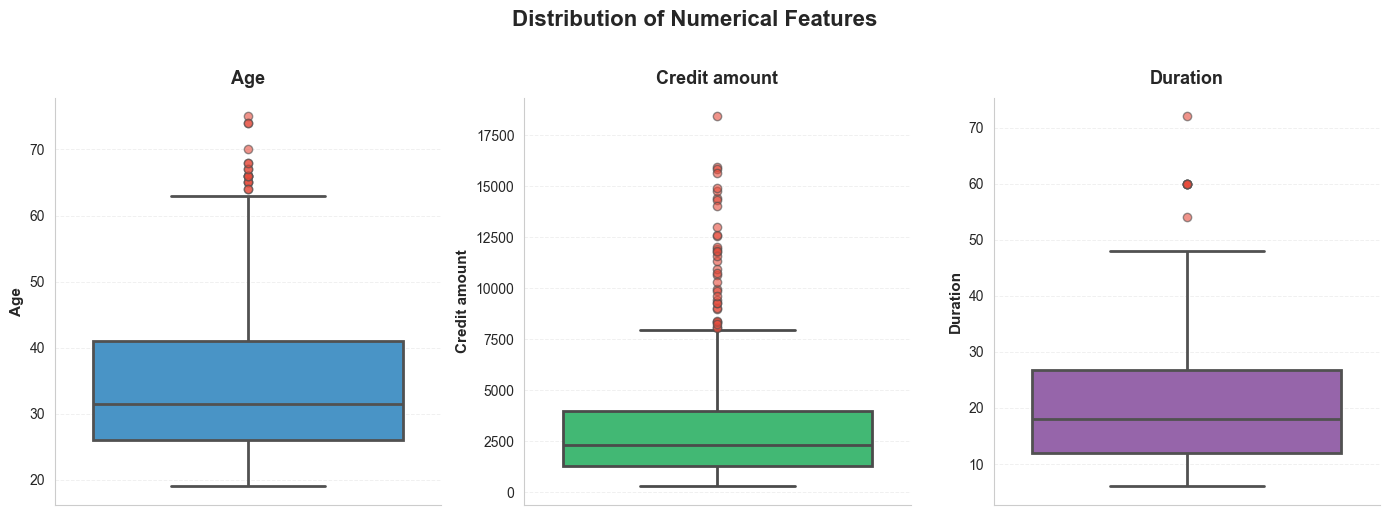

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('white')

colors = ['#3498db', '#2ecc71', '#9b59b6']
columns = ["Age", "Credit amount", "Duration"]

axes_flat = axes.flatten()

for i, col in enumerate(columns):
    ax = axes_flat[i]

    sns.boxplot(y=df[col], color=colors[i], linewidth=2,
                flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, alpha=0.6),
                ax=ax)

    ax.set_title(col, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(col, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [63]:
df[df["Duration"] >= 60]

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [64]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

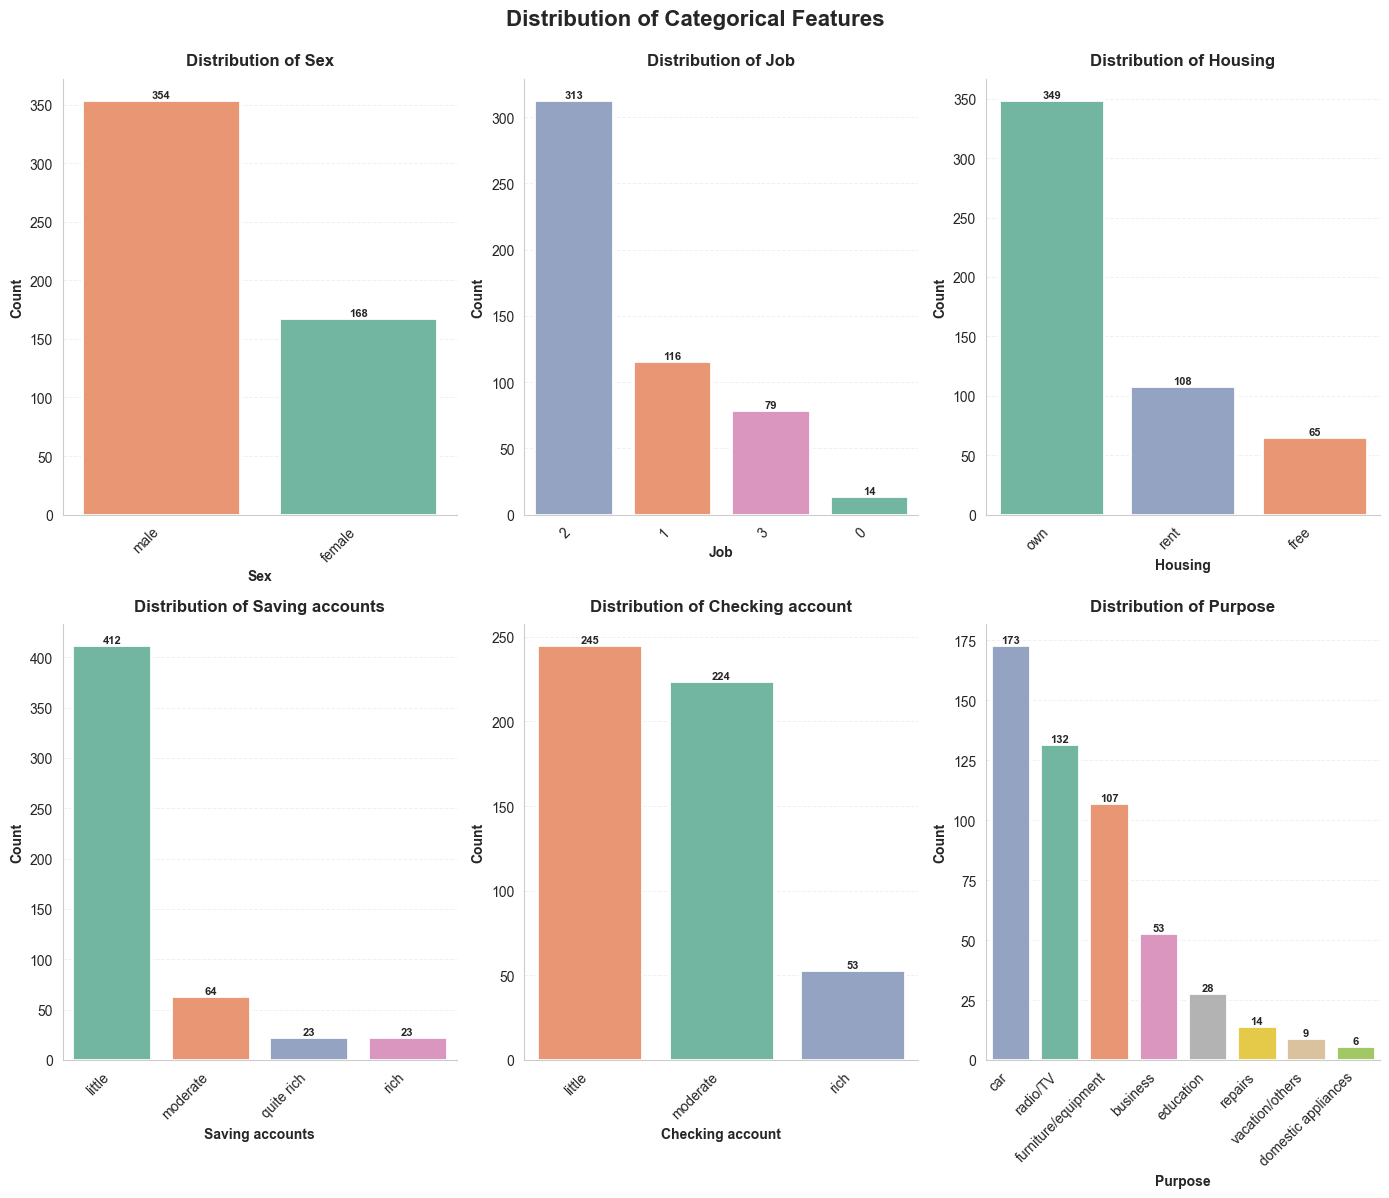

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(14, 12))
fig.patch.set_facecolor('white')

axes_flat = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes_flat[i]

    sns.countplot(data=df, x=col, palette="Set2", hue=col,
                  order=df[col].value_counts().index,
                  edgecolor='white', linewidth=2,
                  legend=False, ax=ax)

    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for container in ax.containers:
        ax.bar_label(container, fontsize=8, fontweight='bold')

plt.suptitle("Distribution of Categorical Features", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [66]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


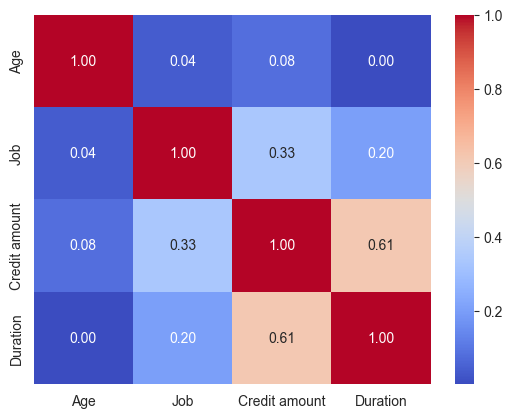

In [67]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [68]:
print(df.groupby("Job")["Credit amount"].mean())

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64


In [69]:
print(df.groupby("Sex")["Credit amount"].mean())

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64


In [70]:
pd.pivot_table(df, values="Credit amount", index = "Housing", columns = "Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


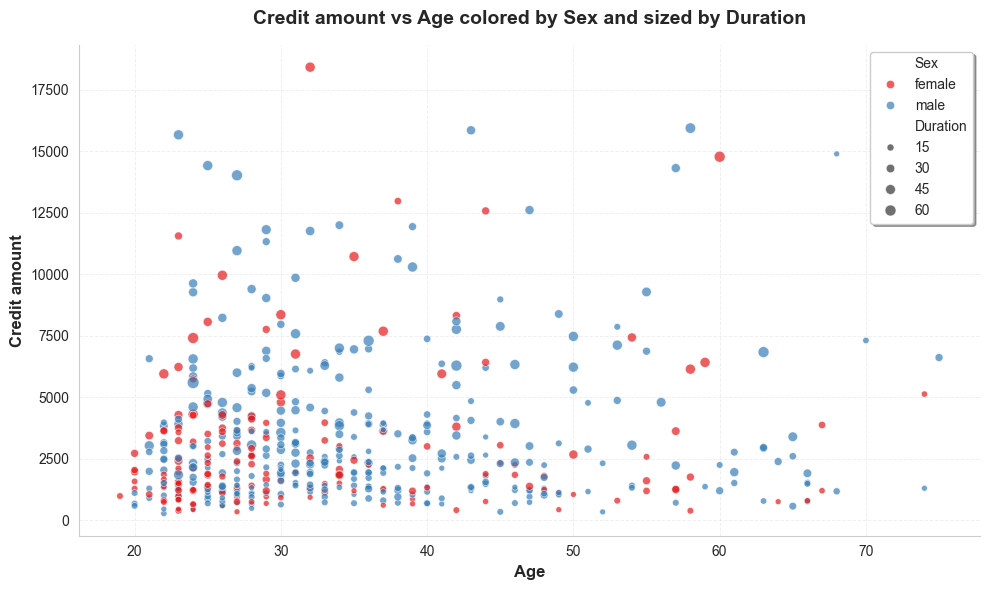

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration",
                alpha=0.7, palette="Set1", edgecolor='white', linewidth=0.5, ax=ax)

plt.title("Credit amount vs Age colored by Sex and sized by Duration",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Age", fontsize=12, fontweight='bold')
plt.ylabel("Credit amount", fontsize=12, fontweight='bold')
plt.legend(fontsize=10, frameon=True, shadow=True, loc='best')
plt.grid(alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

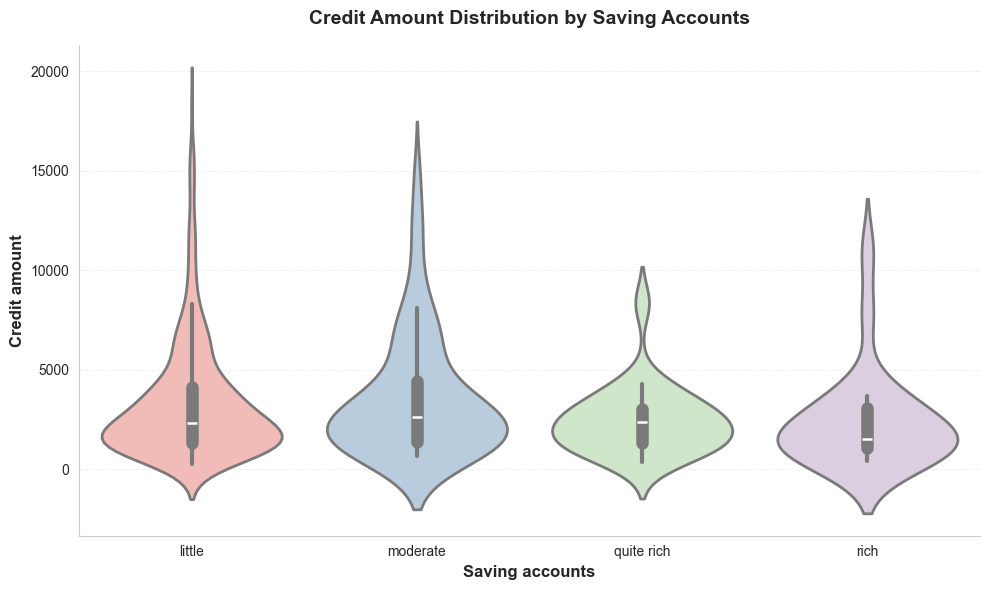

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

sns.violinplot(data=df, x="Saving accounts", y="Credit amount", hue="Saving accounts",
               palette="Pastel1", linewidth=2, ax=ax)

plt.title("Credit Amount Distribution by Saving Accounts",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Saving accounts", fontsize=12, fontweight='bold')
plt.ylabel("Credit amount", fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [73]:
print(df["Risk"].value_counts(normalize = True) * 100)

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64


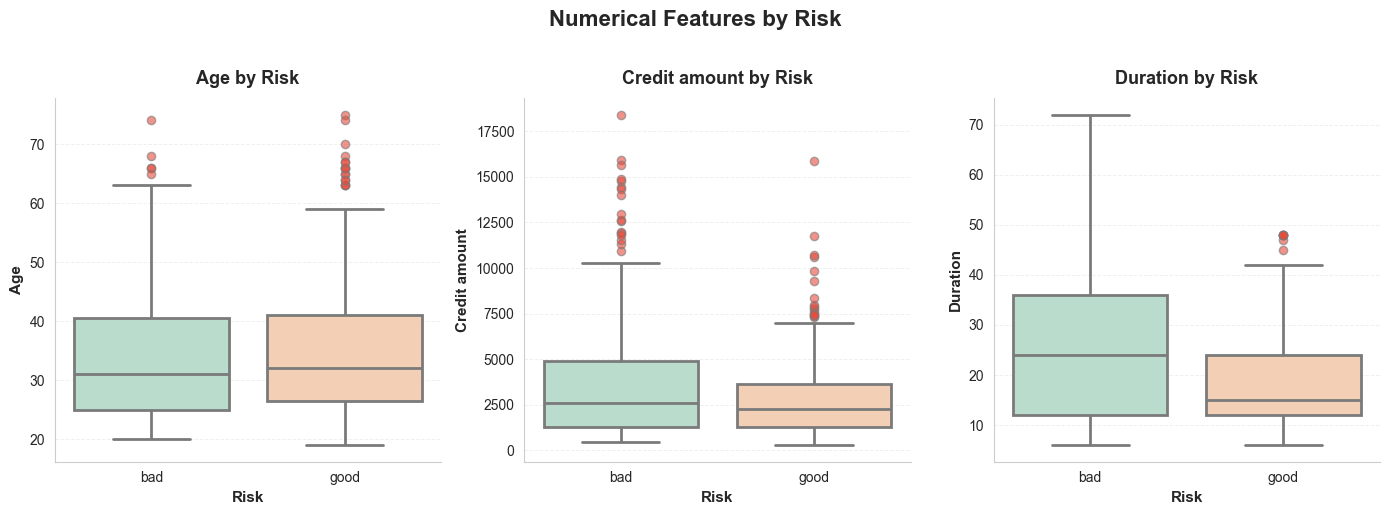

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('white')

columns = ["Age", "Credit amount", "Duration"]
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    ax = axes_flat[i]

    sns.boxplot(data=df, x="Risk", y=col, palette="Pastel2", hue="Risk",
                linewidth=2,
                flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, alpha=0.6),
                ax=ax)

    ax.set_title(f"{col} by Risk", fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Risk", fontsize=11, fontweight='bold')
    ax.set_ylabel(col, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Numerical Features by Risk", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [75]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

In [76]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


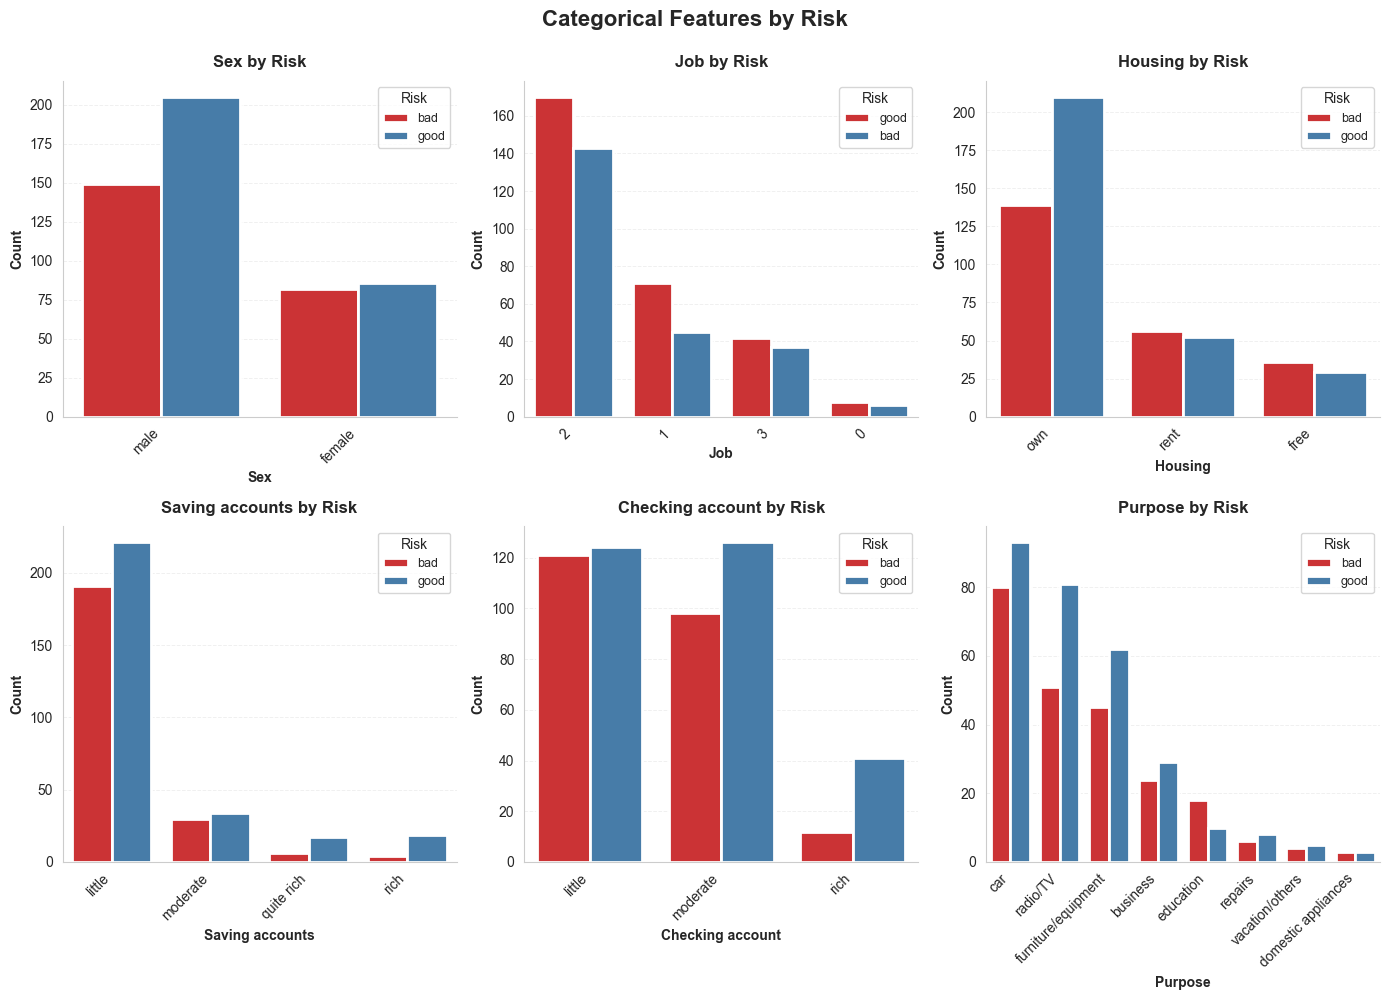

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes_flat = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes_flat[i]

    sns.countplot(data=df, x=col, hue="Risk", palette="Set1",
                  order=df[col].value_counts().index,
                  edgecolor='white', linewidth=2, ax=ax)

    ax.set_title(f"{col} by Risk", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count', fontsize=10, fontweight='bold')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(title='Risk', fontsize=9, title_fontsize=10, frameon=True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Categorical Features by Risk", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [78]:
df.to_csv("data/eda_data.csv")